# Naïve Bayes — Theory & Interview Guide

A concise, interview-ready walkthrough of the **Naïve Bayes** classifier.

1. **Bayes' Theorem** — mathematical foundation
2. **Naïve Bayes assumption** — conditional independence & formula
3. **Types of Naïve Bayes** — Gaussian, Multinomial, Bernoulli, Categorical, Complement (sklearn)
4. **Laplace Smoothing** — zero-frequency problem
5. **Log Probabilities** — numerical stability & underflow prevention
6. **Complement Naïve Bayes** — imbalanced data fix
7. **Out-of-Core Learning** — incremental / streaming training
8. **Pros, Cons & When to Use**
9. **Interview Questions** — top Q&As with answers

> **Companion notebook:** [`03-sentiment-analysis-naive-bayes.ipynb`](03-sentiment-analysis-naive-bayes.ipynb) — IMDB sentiment analysis.


---
## 1. Import Required Libraries

In [1]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.naive_bayes import CategoricalNB, ComplementNB
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris, make_classification
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer

import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")


Libraries imported successfully!


---
## 2. Bayes' Theorem — Mathematical Foundation

Bayes' theorem describes the probability of an event, based on prior knowledge of conditions related to the event.

$$P(A \mid B) = \frac{P(B \mid A) \cdot P(A)}{P(B)}$$

Where:
- $P(A \mid B)$ — **Posterior probability**: probability of hypothesis $A$ given the observed evidence $B$
- $P(B \mid A)$ — **Likelihood**: probability of evidence $B$ given that hypothesis $A$ is true
- $P(A)$ — **Prior probability**: probability of hypothesis $A$ before observing evidence
- $P(B)$ — **Marginal likelihood (Evidence)**: total probability of the evidence

### Example: Play Tennis Dataset

We use a classic dataset where weather conditions determine whether someone plays tennis.

In [2]:
df_tennis = pd.read_csv("../../datasets/playtennis.csv")
print(f"Dataset shape: {df_tennis.shape}")
df_tennis

Dataset shape: (200, 5)


,Outlook,Temperature,Humidity,Wind,PlayTennis
0,Sunny,Hot,High,Weak,No
1,Overcast,Mild,Normal,Strong,No
2,Overcast,Cool,Normal,NaN,Yes
3,Rain,Mild,High,Strong,No
4,Rain,Hot,Normal,Weak,Yes
...,...,...,...,...,...
195,Rain,Mild,High,Weak,Yes
196,Overcast,Hot,High,Strong,Yes
197,Sunny,Mild,Normal,Strong,Yes
198,Rain,Mild,High,Weak,Yes


In [12]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

features   = ['Outlook', 'Temperature', 'Humidity', 'Wind']
new_sample = {'Outlook': 'Sunny', 'Temperature': 'Cool', 'Humidity': 'High', 'Wind': 'Strong'}

X_tennis = df_tennis[features]
y_tennis = df_tennis['PlayTennis']

# Handle nulls using OrdinalEncoder with handle_unknown and SimpleImputer

enc_pipe = Pipeline([
    ('enc', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)),
    ('imp', SimpleImputer(strategy='most_frequent'))
])

X_enc = enc_pipe.fit_transform(X_tennis)
y_enc = (y_tennis == 'Yes').astype(int)

# Bayes via CategoricalNB (needs non-negative integers → shift by 1)
X_enc_shifted = X_enc + 1
cat_nb = CategoricalNB(alpha=1.0)
cat_nb.fit(X_enc_shifted, y_enc)

p_yes = cat_nb.predict_proba(enc_pipe.transform(pd.DataFrame([new_sample])) + 1)[0]
print(f"P(PlayTennis=Yes | {new_sample}) = {p_yes[1]:.4f}")
print(f"P(PlayTennis=No  | {new_sample}) = {p_yes[0]:.4f}")
print(f"Prediction: {'Yes' if p_yes[1] > p_yes[0] else 'No'}")


P(PlayTennis=Yes | {'Outlook': 'Sunny', 'Temperature': 'Cool', 'Humidity': 'High', 'Wind': 'Strong'}) = 0.1622
P(PlayTennis=No  | {'Outlook': 'Sunny', 'Temperature': 'Cool', 'Humidity': 'High', 'Wind': 'Strong'}) = 0.8378
Prediction: No


---
## 3. Naïve Bayes Assumption and Formula Derivation

### The Conditional Independence Assumption

Naïve Bayes makes a **strong (naïve) assumption**: all features are **conditionally independent** given the class label.

$$P(x_1, x_2, \ldots, x_n \mid y) = \prod_{i=1}^{n} P(x_i \mid y)$$

### Full Naïve Bayes Formula

$$P(y \mid x_1, x_2, \ldots, x_n) \propto P(y) \cdot \prod_{i=1}^{n} P(x_i \mid y)$$

The predicted class is:

$$\hat{y} = \arg\max_{y} \; P(y) \cdot \prod_{i=1}^{n} P(x_i \mid y)$$

> This "naïve" assumption rarely holds perfectly in real data, yet the classifier still performs well in practice — especially in NLP tasks.


---
## 7. Types of Naïve Bayes Classifiers

| Variant | Feature Type | Distribution Assumption | Typical Use Case |
|---|---|---|---|
| **GaussianNB** | Continuous | Gaussian (normal) distribution | Iris, general continuous data |
| **MultinomialNB** | Discrete (counts) | Counts or frequencies | Text classification (word counts, TF-IDF) |
| **BernoulliNB** | Binary (0/1) | Binary indicators | Text classification (word presence/absence) |
| **CategoricalNB** | Categorical | Categorical per-feature distribution | Tabular categorical data |
| **ComplementNB** | Discrete (counts) | Complement class distribution | Imbalanced text classification |

### 7.1 Gaussian Naïve Bayes

For continuous features, GaussianNB uses the **probability density function** of the Gaussian distribution:

$$P(x_i \mid y) = \frac{1}{\sqrt{2\pi\sigma_y^2}} \exp\left(-\frac{(x_i - \mu_y)^2}{2\sigma_y^2}\right)$$

> **Key point:** Because GaussianNB uses a *continuous* PDF (not discrete counts), Laplace smoothing is **not applicable** — the variance $\sigma^2$ serves a similar regularisation role. The PDF value is never exactly zero as long as $\sigma > 0$.


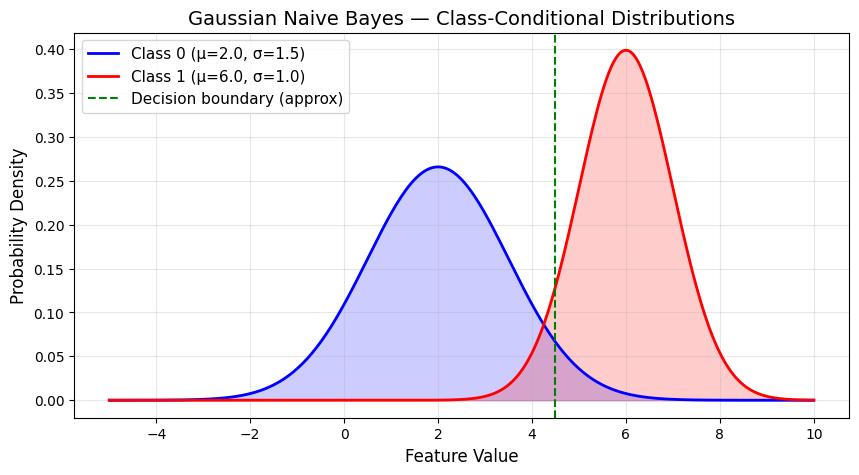


P(x=3.0 | Class 0) = 0.2130
P(x=3.0 | Class 1) = 0.0044
=> x=3.0 is more likely under Class 0


In [4]:
# Gaussian PDF visualization
def gaussian_pdf(x, mean, std):
    """Compute Gaussian probability density."""
    exponent = np.exp(-((x - mean) ** 2) / (2 * std ** 2))
    return (1 / (np.sqrt(2 * np.pi) * std)) * exponent

x_range = np.linspace(-5, 10, 300)
mean_0, std_0 = 2.0, 1.5
mean_1, std_1 = 6.0, 1.0

plt.figure(figsize=(10, 5))
plt.plot(x_range, gaussian_pdf(x_range, mean_0, std_0), 'b-', lw=2,
         label=f'Class 0 (\u03bc={mean_0}, \u03c3={std_0})')
plt.plot(x_range, gaussian_pdf(x_range, mean_1, std_1), 'r-', lw=2,
         label=f'Class 1 (\u03bc={mean_1}, \u03c3={std_1})')
plt.axvline(x=4.5, color='green', ls='--', label='Decision boundary (approx)')
plt.fill_between(x_range, gaussian_pdf(x_range, mean_0, std_0), alpha=0.2, color='blue')
plt.fill_between(x_range, gaussian_pdf(x_range, mean_1, std_1), alpha=0.2, color='red')
plt.xlabel('Feature Value', fontsize=12)
plt.ylabel('Probability Density', fontsize=12)
plt.title('Gaussian Naive Bayes — Class-Conditional Distributions', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

test_x = 3.0
print(f"\nP(x={test_x} | Class 0) = {gaussian_pdf(test_x, mean_0, std_0):.4f}")
print(f"P(x={test_x} | Class 1) = {gaussian_pdf(test_x, mean_1, std_1):.4f}")
print(f"=> x={test_x} is more likely under Class 0")

GaussianNB on Iris — Accuracy: 1.0000

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



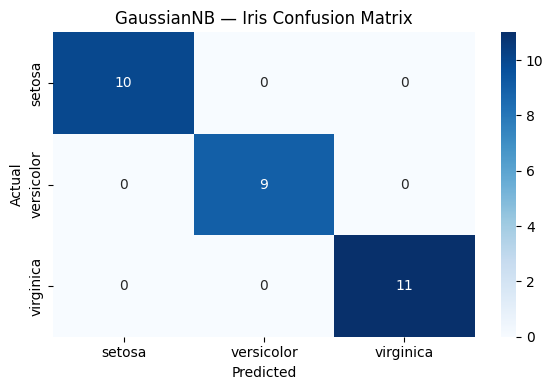

In [5]:
# GaussianNB on the Iris dataset
iris = load_iris()
X_iris, y_iris = iris.data, iris.target

X_train_iris, X_test_iris, y_train_iris, y_test_iris = train_test_split(
    X_iris, y_iris, test_size=0.2, random_state=42)

gnb = GaussianNB()
gnb.fit(X_train_iris, y_train_iris)
y_pred_iris = gnb.predict(X_test_iris)

print(f"GaussianNB on Iris — Accuracy: {accuracy_score(y_test_iris, y_pred_iris):.4f}")
print(f"\n{classification_report(y_test_iris, y_pred_iris, target_names=iris.target_names)}")

# Confusion matrix
cm = confusion_matrix(y_test_iris, y_pred_iris)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.title('GaussianNB — Iris Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

### 7.2 Multinomial Naïve Bayes — Text Classification

MultinomialNB is suited for **discrete feature counts** — typically word counts or TF-IDF scores.

$$P(x_i \mid y) = \frac{\text{count}(x_i, y) + \alpha}{\sum_{j} \text{count}(x_j, y) + \alpha \cdot |V|}$$

Where $|V|$ is the vocabulary size and $\alpha$ is the Laplace smoothing parameter.

**Multinomial NB update rule** (from full parameterisation):
$$\hat{y} = \arg\max_{y} \left[ \log P(y) + \sum_{i} x_i \cdot \log P(w_i \mid y) \right]$$


In [6]:
# MultinomialNB — spam classifier using word counts
corpus = [
    "buy cheap medicine online now",   "free money win lottery prize",
    "claim your free gift today",      "limited offer buy now exclusive",
    "meeting scheduled for tomorrow",  "please review the attached report",
    "project deadline next friday",    "team lunch at noon today",
    "quarterly review results attached","click here for exclusive deal now",
]
labels = [1, 1, 1, 1, 0, 0, 0, 0, 0, 1]   # 1 = spam

pipeline_mnb = Pipeline([
    ('vec', CountVectorizer()),
    ('clf', MultinomialNB(alpha=1.0))
])
pipeline_mnb.fit(corpus, labels)

test_msgs = ["free prize click here", "see you at the meeting tomorrow"]
for msg, pred, prob in zip(test_msgs,
                            pipeline_mnb.predict(test_msgs),
                            pipeline_mnb.predict_proba(test_msgs)):
    print(f"{'SPAM' if pred else 'NOT SPAM':9s} | P(spam)={prob[1]:.3f} | '{msg}'")

# Top spam words
vocab  = pipeline_mnb.named_steps['vec'].get_feature_names_out()
scores = pipeline_mnb.named_steps['clf'].feature_log_prob_[1] - \
         pipeline_mnb.named_steps['clf'].feature_log_prob_[0]
print("\nTop spam-indicating words:")
for i in np.argsort(scores)[-6:][::-1]:
    print(f"  {vocab[i]:<15}  log-odds = {scores[i]:+.2f}")


SPAM      | P(spam)=0.949 | 'free prize click here'
NOT SPAM  | P(spam)=0.046 | 'see you at the meeting tomorrow'

Top spam-indicating words:
  now              log-odds = +1.32
  buy              log-odds = +1.04
  free             log-odds = +1.04
  exclusive        log-odds = +1.04
  your             log-odds = +0.63
  win              log-odds = +0.63


### 7.3 Bernoulli Naïve Bayes — Binary Feature Indicators

BernoulliNB works with **binary feature vectors** — each feature is 0 (absent) or 1 (present). Unlike MultinomialNB, it **explicitly penalises the absence of a word**.

$$P(x_i \mid y) = P(i \mid y)^{x_i} \cdot \big(1 - P(i \mid y)\big)^{(1 - x_i)}$$

- If $x_i = 1$: contributes $P(i \mid y)$
- If $x_i = 0$: contributes $1 - P(i \mid y)$  ← **absence is informative**


In [7]:
# BernoulliNB — same corpus, binary word presence (not counts)
pipeline_bnb = Pipeline([
    ('vec', CountVectorizer(binary=True)),   # binary=True → 0 or 1 per word
    ('clf', BernoulliNB(alpha=1.0))
])
pipeline_bnb.fit(corpus, labels)

print("BernoulliNB vs MultinomialNB on the same messages:")
print(f"{'Message':<40}  {'MNB':>8}  {'BNB':>8}")
print("-" * 62)
for msg in test_msgs:
    mnb_p = pipeline_mnb.predict_proba([msg])[0][1]
    bnb_p = pipeline_bnb.predict_proba([msg])[0][1]
    print(f"{msg:<40}  {mnb_p:>8.3f}  {bnb_p:>8.3f}")

print("\nKey difference:")
print("  MultinomialNB — uses word counts   (repeating a word changes the score)")
print("  BernoulliNB   — uses word presence (0 or 1; ABSENCE is also informative)")


BernoulliNB vs MultinomialNB on the same messages:
Message                                        MNB       BNB
--------------------------------------------------------------
free prize click here                        0.949     0.961
see you at the meeting tomorrow              0.046     0.012

Key difference:
  MultinomialNB — uses word counts   (repeating a word changes the score)
  BernoulliNB   — uses word presence (0 or 1; ABSENCE is also informative)


---
### 7.4 Categorical Naïve Bayes — Tabular Categorical Data

> **Interview Question:** *I have 4 features: gender (categorical), married (categorical), age (numerical), height (numerical). Can I apply Categorical Naïve Bayes?*

**Answer — Three approaches:**

| Approach | Description | Trade-off |
|---|---|---|
| **Discretize** numerical → categorical | Bin age/height into groups | Fast, but information loss |
| **Mixed NB** | GaussianNB for numbers + CategoricalNB for strings | More accurate, needs custom code |
| **Use a different model** | Decision Tree / Random Forest | Handles mixed types natively |

`sklearn.naive_bayes.CategoricalNB` assumes each feature has its own categorical distribution and applies Laplace smoothing per feature.


In [8]:
from sklearn.naive_bayes import CategoricalNB
from sklearn.preprocessing import OrdinalEncoder

encoder = OrdinalEncoder()
X_encoded = encoder.fit_transform(X_tennis)
y_encoded = (y_tennis == 'Yes').astype(int)

cat_nb = CategoricalNB(alpha=1.0)
cat_nb.fit(X_encoded, y_encoded)

cat_preds = ['Yes' if p == 1 else 'No' for p in cat_nb.predict(X_encoded)]
print(f"CategoricalNB Training Accuracy: {accuracy_score(y_tennis, cat_preds):.4f}")

print("\nLearned P(feature | class=Yes) — higher = more indicative of Yes:")
for i, feat in enumerate(features):
    cats  = encoder.categories_[i]
    probs = np.exp(cat_nb.feature_log_prob_[i][1])
    print(f"  {feat}: {dict(zip(cats, probs.round(3)))}")

# Predict new sample
new_enc = encoder.transform(pd.DataFrame([new_sample]))
pred    = 'Yes' if cat_nb.predict(new_enc)[0] == 1 else 'No'
print(f"\nNew sample {new_sample}\nCategoricalNB → {pred}")


ValueError: Input X contains NaN.
CategoricalNB does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

---
## 8. Laplace Smoothing — The Zero-Frequency Problem

### The Problem

If a feature value **never appears** with a particular class during training:

$$P(x_i \mid y) = 0$$

Since Naïve Bayes **multiplies** all conditional probabilities, **one zero kills the entire product**:

$$P(y \mid x_1, \ldots, x_n) \propto P(y) \times \ldots \times 0 \times \ldots = 0$$

### Laplace (Add-1) Smoothing

$$P(x_i \mid y) = \frac{\text{count}(x_i, y) + \alpha}{\text{count}(y) + \alpha \cdot |V|}$$

Where:
- $\alpha$ = smoothing parameter (typically 1)
- $|V|$ = number of unique values for the feature

---
## 9. Numerical Stability — Log Probabilities

### The Underflow Problem

Naïve Bayes multiplies many conditional probabilities together:

$$P(y \mid \mathbf{x}) \propto P(y) \cdot \prod_{i=1}^{n} P(x_i \mid y)$$

With many features, this product can become **smaller than the minimum float64 value** ($\approx 5 \times 10^{-324}$), causing it to **underflow to zero** — even when the true probability is non-zero.

**Example:** $0.01^{300} = 10^{-600}$ — impossible to represent; rounds to `0.0`.

### Solution: Work in Log-Space

$$\log P(y \mid \mathbf{x}) \propto \log P(y) + \sum_{i=1}^{n} \log P(x_i \mid y)$$

| Property | Why it helps |
|---|---|
| **Products → sums** | $\log(A \cdot B) = \log A + \log B$ — no underflow |
| **Monotonic** | $\arg\max P = \arg\max \log P$ — predicted class unchanged |
| **Numerically stable** | Sums of log values stay in representable range |

> **Interview Question:** *Why do we use log probabilities in Naïve Bayes?*
> 
> **Answer:** To prevent **numerical underflow**. When multiplying many small probabilities (each $< 1$), the product shrinks toward zero faster than floating-point can represent. Converting to log-space turns multiplications into additions, keeping values numerically stable. Since $\log$ is monotonic, the $\arg\max$ — and hence the predicted class — is identical.

`Here also if the probability of a feature is 0` — log(0) is undefined, so we must ensure no zero probabilities (e.g., via Laplace smoothing) to avoid `-inf` values in log-space.

---
## 9. Advantages, Disadvantages & When to Use

### Advantages

| # | Advantage |
|---|---|
| 1 | **Extremely fast** training and prediction — $O(n \cdot d)$ time complexity |
| 2 | Works well with **small training datasets** |
| 3 | Handles **high-dimensional data** effectively (e.g., text with thousands of features) |
| 4 | **Simple to implement** and easy to interpret |
| 5 | **Good baseline** for text classification tasks |
| 6 | Not sensitive to **irrelevant features** (they cancel out across classes) |
| 7 | Performs well even when the independence assumption is **partially violated** |

### Disadvantages

| # | Disadvantage |
|---|---|
| 1 | **Strong independence assumption** rarely holds in real-world data |
| 2 | Poor **probability estimates** (posteriors are often too extreme) |
| 3 | **Zero-frequency problem** — requires smoothing to avoid zeros |
| 4 | Cannot learn **feature interactions** (e.g., XOR-like patterns) |
| 5 | Outperformed by more complex models (SVM, Random Forest, Neural Nets) on **large datasets** |
| 6 | Sensitive to **correlated features** — violates the core assumption |

### When to Use Naive Bayes

- **Text classification** — spam detection, sentiment analysis, topic categorization
- **Real-time prediction** — where speed matters more than marginal accuracy gains
- **Small or medium-sized datasets** — where you need a quick, reliable baseline
- **High-dimensional sparse data** — e.g., bag-of-words representations
- As a **benchmark / baseline** to compare against more complex models

---
## 10. Complement Naïve Bayes

### What is Complement Naïve Bayes (CNB)?

**ComplementNB** was introduced to address a known weakness of MultinomialNB on **imbalanced datasets**. Instead of estimating $P(x_i \mid y = c)$ (probability of a feature given class $c$), it estimates $P(x_i \mid y \neq c)$ — the probability given the **complement** of class $c$:

$$w_{ci} = \log \frac{\alpha + \sum_{j \,:\, y_j \neq c} x_{ji}}{\alpha + \sum_{j \,:\, y_j \neq c} \sum_k x_{jk}}$$

**Classification rule** (minimise complement score, not maximise posterior):

$$\hat{y} = \arg\min_{c} \sum_{i} \hat{w}_{ci} \cdot x_i$$

where weights are normalised by their L2 norm.

### Why it works better on imbalanced data

- MultinomialNB estimates class-conditional distributions using **only the samples in each class** — minority classes have much less data → noisy estimates.
- ComplementNB uses **all other classes** to estimate each weight → more data, lower variance.
- Empirically outperforms MultinomialNB on text classification benchmarks.

> **When to use:** imbalanced text classification, news categorisation, document routing.


In [ ]:
# Compare MultinomialNB vs ComplementNB on the same text corpus
X_text = CountVectorizer().fit_transform(corpus)
y_text = np.array(labels)

print(f"{'Model':<28}  {'Train Acc':>9}")
print("-" * 42)
for name, model in [
    ("MultinomialNB  (alpha=1)", MultinomialNB(alpha=1.0)),
    ("ComplementNB   (alpha=1)", ComplementNB(alpha=1.0)),
    ("BernoulliNB    (alpha=1)", BernoulliNB(alpha=1.0)),
]:
    X_fit = CountVectorizer(binary='Bernoulli' in name).fit_transform(corpus)
    model.fit(X_fit, y_text)
    acc = accuracy_score(y_text, model.predict(X_fit))
    print(f"  {name:<26}  {acc:>9.4f}")

print("\nComplementNB is especially helpful for imbalanced class distributions.")


Model                         Train Acc
------------------------------------------
  MultinomialNB  (alpha=1)       1.0000
  ComplementNB   (alpha=1)       1.0000
  BernoulliNB    (alpha=1)       1.0000

ComplementNB is especially helpful for imbalanced class distributions.


---
## 11. Out-of-Core (Incremental) Learning with Naïve Bayes

### What is Out-of-Core Learning?

**Out-of-core** (incremental / online) learning trains on data **too large to fit in memory** by processing it in mini-batches. scikit-learn exposes this via `partial_fit()`.

### Why Naïve Bayes is Ideal for Out-of-Core Learning

| Property | Explanation |
|---|---|
| **Stores only statistics** | Class priors + per-class feature stats (counts, means, variances) — not raw data |
| **`partial_fit()` API** | Incrementally updates sufficient statistics from each chunk |
| **Constant memory** | Memory usage is $O(\text{classes} \times \text{features})$, independent of $n$ samples |
| **Mathematically equivalent** | Streaming result = batch result (for GaussianNB, MultinomialNB, BernoulliNB) |

> **Interview Question:** *What makes Naïve Bayes suitable for out-of-core learning?*
>
> **Answer:** NB only needs to maintain summary statistics, not the entire dataset. `partial_fit()` updates these incrementally per batch. Memory usage is constant regardless of dataset size.


In [ ]:
# Out-of-core training with partial_fit() — process data in chunks
X_large, y_large = make_classification(n_samples=10_000, n_features=20,
                                        n_informative=10, random_state=42)
classes    = np.unique(y_large)
gnb_online = GaussianNB()

for i in range(0, len(X_large), 1000):
    gnb_online.partial_fit(X_large[i:i+1000], y_large[i:i+1000], classes=classes)

gnb_batch = GaussianNB().fit(X_large, y_large)

print(f"Batch  GaussianNB accuracy : {accuracy_score(y_large, gnb_batch.predict(X_large)):.4f}")
print(f"Online GaussianNB accuracy : {accuracy_score(y_large, gnb_online.predict(X_large)):.4f}")
print("\nResults are identical — partial_fit() stores only statistics, not the data.")
print("Memory is O(classes × features), independent of dataset size.")


Batch  GaussianNB accuracy : 0.7941
Online GaussianNB accuracy : 0.7941

Results are identical — partial_fit() stores only statistics, not the data.
Memory is O(classes × features), independent of dataset size.


---
## 12. Interview Questions — Naïve Bayes

A curated set of top interview questions with concise, accurate answers.

---

### Q1. What is the "naïve" assumption in Naïve Bayes?

**Answer:** All features are assumed to be **conditionally independent** given the class label:

$$P(x_1, x_2, \ldots, x_n \mid y) = \prod_{i=1}^{n} P(x_i \mid y)$$

This rarely holds in practice, but the model often performs surprisingly well despite this violation.

---

### Q2. Why do we use log probabilities in Naïve Bayes?

**Answer:** To prevent **numerical underflow**. Multiplying many small probabilities together (each $\in (0,1)$) produces values too small for floating-point to represent. Log-space converts multiplications to additions:

$$\log P(y|\mathbf{x}) \propto \log P(y) + \sum_i \log P(x_i|y)$$

Since $\log$ is **monotonic**, the $\arg\max$ is preserved — the predicted class is identical.

---

### Q3. What is the zero-frequency problem? How is it solved?

**Answer:** If a feature value never appears with a particular class in training data, $P(x_i | y) = 0$, which **zeroes out the entire posterior** — no matter how strong the other evidence.

**Solution — Laplace (Add-$\alpha$) Smoothing:**

$$P(x_i \mid y) = \frac{\text{count}(x_i, y) + \alpha}{\text{count}(y) + \alpha \cdot |V|}$$

With $\alpha = 1$ (add-one smoothing), unseen feature-class combinations get a small positive probability instead of zero.

---

### Q4. Why is Laplace smoothing NOT applied to Gaussian Naïve Bayes?

**Answer:** GaussianNB uses a **continuous PDF**, not discrete counts:

$$P(x_i \mid y) = \frac{1}{\sqrt{2\pi\sigma_y^2}} \exp\!\left(-\frac{(x_i - \mu_y)^2}{2\sigma_y^2}\right)$$

The Gaussian PDF is **never exactly zero** as long as $\sigma > 0$. There are no zero-frequency events because the probability of any single continuous value is already infinitesimal. The variance $\sigma^2$ plays the regularisation role that $\alpha$ plays in discrete variants.

---

### Q5. When would you use GaussianNB vs MultinomialNB vs BernoulliNB?

| Variant | Use when... |
|---|---|
| **GaussianNB** | Features are continuous (measurements, sensor data, age, height) |
| **MultinomialNB** | Features are word/token **counts** or TF-IDF values — long documents |
| **BernoulliNB** | Features are **binary** (word present/absent) — short documents, spam detection |
| **CategoricalNB** | Features are nominal categories (gender, colour, grade) |
| **ComplementNB** | Text classification with **imbalanced classes** |

---

### Q6. Can Naïve Bayes handle mixed data types (categorical + numerical)?

**Answer:** Not directly with a single variant, but there are three approaches:
1. **Discretize** numerical features into bins → use CategoricalNB (information loss)
2. **Mixed NB**: use GaussianNB for continuous features and CategoricalNB/MultinomialNB for categorical ones — combine log-posteriors at prediction time
3. **Use a different model**: Decision Trees / Random Forests handle mixed types natively

---

### Q7. Is Naïve Bayes a generative or discriminative model?

**Answer:** **Generative**. It models the joint distribution $P(x, y) = P(y) \cdot P(x|y)$ and then uses Bayes' theorem to compute $P(y|x)$. Discriminative models (Logistic Regression, SVM) directly model $P(y|x)$.

---

### Q8. Does Naïve Bayes require feature scaling (normalization/standardization)?

**Answer:** **No** — for GaussianNB it computes the mean and variance per class internally; for discrete variants (MultinomialNB, BernoulliNB, CategoricalNB) it uses counts, not distances. No feature scaling is needed.

---

### Q9. What is the Bias-Variance trade-off for Naïve Bayes?

**Answer:**
- **High Bias**: The independence assumption introduces structural bias — the model is too simple to capture feature correlations. This means consistent underfitting if features are strongly correlated.
- **Low Variance**: Because the model has few parameters (one prior + per-class per-feature statistics), it is stable across different training sets and rarely overfits.

**NB sits on the high-bias / low-variance end of the spectrum** — a great baseline that generalises well with limited data.

---

### Q10. What is Complement Naïve Bayes and when should you use it?

**Answer:** ComplementNB estimates the probability of features given **every class except** $c$:
$$w_{ci} = \log \frac{\alpha + \sum_{j: y_j \neq c} x_{ji}}{\alpha + \sum_{j: y_j \neq c} \sum_k x_{jk}}$$

It acts as a **correction** to MultinomialNB and empirically outperforms it on **imbalanced text datasets** because it uses the complement distribution, which is estimated from more data.

---

### Q11. What makes Naïve Bayes suitable for out-of-core (incremental) learning?

**Answer:** NB only needs to maintain **summary statistics** (class counts, feature counts/means/variances), not the full training dataset. The `partial_fit()` API in scikit-learn lets you stream data in mini-batches and update these statistics incrementally. Memory usage is $O(\text{classes} \times \text{features})$, **independent of dataset size**.

---

### Q12. What are the main failure modes of Naïve Bayes?

**Answer:**
1. **Correlated features** — violates the independence assumption, degrades calibration
2. **Poor probability estimates** — posteriors are often too extreme (close to 0 or 1)
3. **Feature interactions** — cannot learn XOR-type patterns or polynomial interactions
4. **Zero frequency without smoothing** — collapses to zero posterior
5. **Imbalanced data** — MultinomialNB may over-predict the majority class (use ComplementNB)


---
## Summary

| Concept | Key Take-away |
|---|---|
| **Bayes' Theorem** | $P(A\|B) = \frac{P(B\|A)\cdot P(A)}{P(B)}$ — foundation of probabilistic classifiers |
| **Naïve Assumption** | Conditional independence: $P(\mathbf{x}\|y) = \prod_i P(x_i\|y)$ |
| **Laplace Smoothing** | Add $\alpha$ to counts; prevents zero-probability collapse for discrete variants |
| **Log Probabilities** | Convert products to sums; prevents numerical underflow with many features |
| **GaussianNB** | Continuous features; uses Gaussian PDF; variance replaces Laplace smoothing |
| **MultinomialNB** | Word counts / frequencies; standard choice for text classification |
| **BernoulliNB** | Binary word presence; penalises absent terms; better for short docs |
| **CategoricalNB** | Nominal categories; handles mixed data via discretisation or mixed NB |
| **ComplementNB** | Uses complement class distribution; outperforms MultinomialNB on imbalanced data |
| **Out-of-Core** | `partial_fit()` enables streaming/incremental training; constant memory usage |
| **Generative model** | Models $P(x,y)$; high bias, low variance; strong NLP baseline |

> **Next:** See [`03-sentiment-analysis-naive-bayes.ipynb`](03-sentiment-analysis-naive-bayes.ipynb) for a hands-on IMDB sentiment analysis project using these classifiers.
